# Group 1 LAA Project Report
#### Members:
##### Aarcha Mukesh MDS202501
##### Aarushi Kumar MDS202502
##### Abhisri Mohan MDS202503
##### Agnivesh Chatterjee MDS202504

# Eigenfaces for Recognition — From-Scratch Reproduction

Reproduces the methodology of Turk & Pentland, *Eigenfaces for Recognition*, **J. Cognitive Neuroscience** 3(1), 1991.

The implementation uses **only NumPy and Matplotlib** for the algorithm itself; `scikit-learn` is used **only** to fetch the Olivetti faces dataset. Notation matches the paper:

| Symbol | Meaning | Shape |
|---|---|---|
| $\Gamma_i$ | $i$-th face image as a vector | $N^2$ |
| $\Psi$ | mean face (eq. above eq. 1) | $N^2$ |
| $\Phi_i = \Gamma_i - \Psi$ | mean-centered face | $N^2$ |
| $A = [\Phi_1\ \Phi_2\ \cdots\ \Phi_M]$ | data matrix | $N^2 \times M$ |
| $C = \tfrac1M A A^\top$ | covariance (eq. 3) | $N^2 \times N^2$ |
| $L = A^\top A$ | reduced Gram matrix (eq. between 5 and 6) | $M \times M$ |
| $\mathbf{v}_l$ | eigenvector of $L$ (eq. 4) | $M$ |
| $\mathbf{u}_l$ | eigenface (eq. 6) | $N^2$ |
| $\omega_k = \mathbf{u}_k^\top(\Gamma - \Psi)$ | weight (eq. 7) | scalar |
| $\Omega = [\omega_1, \ldots, \omega_{M'}]^\top$ | pattern vector | $M'$ |
| $\varepsilon_k^2 = \lVert \Omega - \Omega_k \rVert^2$ | distance to class $k$ (eq. 8) | scalar |
| $\varepsilon^2 = \lVert \Phi - \Phi_f \rVert^2$ | distance from face space (eq. 9) | scalar |

## 1. Imports and dataset

We use the Olivetti faces dataset (AT&T): 40 subjects × 10 images each, 64×64 grayscale, taken under controlled conditions. This is the standard stand-in for the kind of controlled imagery Turk & Pentland used. The paper used $M = 16$ images of 16 subjects; we'll have far more.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Plot defaults
plt.rcParams["image.cmap"]   = "gray"
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["figure.dpi"]   = 110

In [5]:
def load_olivetti():
    """Load Olivetti faces. Tries sklearn first; falls back to a known mirror."""
    try:
        from sklearn.datasets import fetch_olivetti_faces
        d = fetch_olivetti_faces()
        return d.images.astype(np.float64), d.target.astype(int)
    except Exception as e:
        print(f"sklearn fetch failed ({e}); trying mirror...")
        import urllib.request, scipy.io as sio, io
        # Roweis mirror; if this also fails, point user to manual download
        url = "https://cs.nyu.edu/~roweis/data/olivettifaces.mat"
        with urllib.request.urlopen(url, timeout=60) as r:
            buf = io.BytesIO(r.read())
        m = sio.loadmat(buf)
        # Roweis layout: 4096 x 400, columns are images, 10 imgs per subject
        faces = m["faces"].T.reshape(-1, 64, 64).astype(np.float64) / 255.0
        targets = np.repeat(np.arange(40), 10)
        return faces, targets

images, targets = load_olivetti()
print("images:", images.shape, " dtype:", images.dtype,
      " range:", images.min(), images.max())
print("targets:", targets.shape, " unique subjects:", len(np.unique(targets)))

images: (400, 64, 64)  dtype: float64  range: 0.0 1.0
targets: (400,)  unique subjects: 40


### A peek at the dataset (mimics paper's Figure 1a)

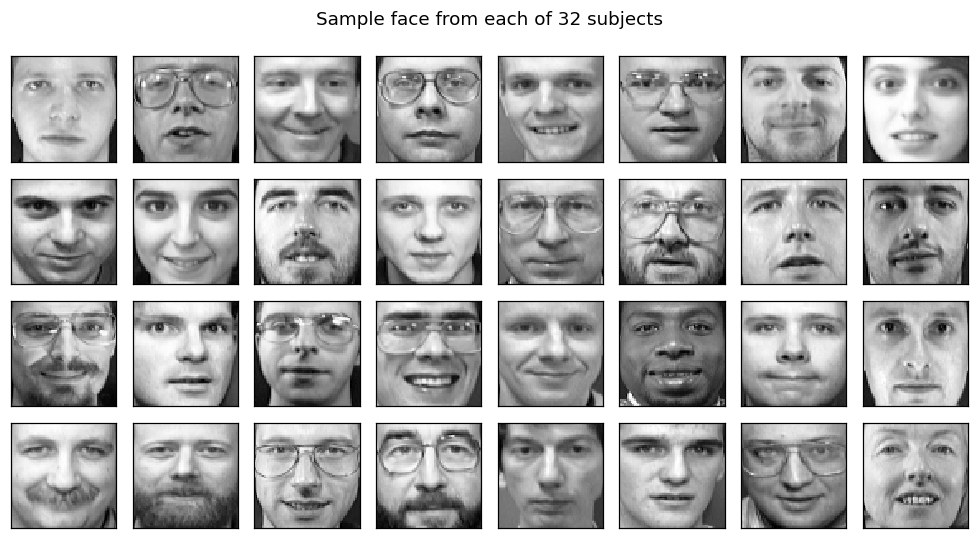

In [6]:
fig, axes = plt.subplots(4, 8, figsize=(9, 5))
for i, ax in enumerate(axes.flat):
    # one image per subject for the first 32 subjects
    subj = i
    idx = np.where(targets == subj)[0][0]
    ax.imshow(images[idx])
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Sample face from each of 32 subjects")
plt.tight_layout(); plt.show()

### Train / test split

We hold out 3 of each subject's 10 images for evaluation, using the remaining 7 to build face space. So $M = 40 \times 7 = 280$ training images (compare to the paper's $M = 16$).

In [7]:
N_PER_SUBJ_TRAIN = 7
H, W = images.shape[1], images.shape[2]
N2 = H * W

train_idx, test_idx = [], []
rng = np.random.default_rng(42)
for s in np.unique(targets):
    idx = np.where(targets == s)[0]
    rng.shuffle(idx)
    train_idx.extend(idx[:N_PER_SUBJ_TRAIN])
    test_idx.extend(idx[N_PER_SUBJ_TRAIN:])

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

X_train = images[train_idx].reshape(-1, N2)   # (M, N^2)
y_train = targets[train_idx]
X_test  = images[test_idx].reshape(-1, N2)
y_test  = targets[test_idx]

M = X_train.shape[0]
print(f"M (training images) = {M}")
print(f"N^2 (vector dim)    = {N2}")
print(f"test set size       = {X_test.shape[0]}")

M (training images) = 280
N^2 (vector dim)    = 4096
test set size       = 120


## 2. The mean face $\Psi$ (paper's Figure 1b)

$$\Psi = \frac{1}{M}\sum_{n=1}^{M} \Gamma_n.$$

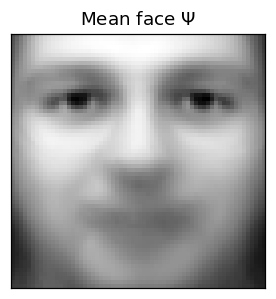

In [8]:
Psi = X_train.mean(axis=0)            # (N^2,)

plt.figure(figsize=(3, 3))
plt.imshow(Psi.reshape(H, W))
plt.title(r"Mean face $\Psi$"); plt.xticks([]); plt.yticks([])
plt.show()

## 3. Mean-centering and the data matrix $A$

Each face deviates from the average by $\Phi_i = \Gamma_i - \Psi$. We assemble the data matrix
$$A = [\Phi_1\ \Phi_2\ \cdots\ \Phi_M] \in \mathbb{R}^{N^2 \times M}.$$

In [9]:
Phi_train = X_train - Psi             # (M, N^2)
A = Phi_train.T                       # (N^2, M)
print("A shape:", A.shape)

A shape: (4096, 280)


## 4. Eigenfaces via the $M \times M$ trick (eqs. 4–6)

The covariance matrix $C = \tfrac1M A A^\top$ is $N^2 \times N^2 = 4096 \times 4096$ here — too large to diagonalize directly when $N^2 \gg M$. The paper's key trick:

If $\mathbf{v}_l$ is an eigenvector of the much smaller $M \times M$ matrix
$$L = A^\top A, \quad L \mathbf{v}_l = \mu_l \mathbf{v}_l,$$
then premultiplying by $A$ gives
$$AA^\top (A\mathbf{v}_l) = \mu_l (A\mathbf{v}_l),$$
so **$A\mathbf{v}_l$ is an eigenvector of $AA^\top$** (eq. 5). The eigenfaces are then
$$\mathbf{u}_l = \sum_{k=1}^M v_{lk} \Phi_k, \qquad l = 1, \ldots, M \qquad (\text{eq. 6})$$
which is exactly $A\mathbf{v}_l$ in matrix form, normalized to unit length so $\mathbf{u}_l^\top \mathbf{u}_k = \delta_{lk}$ (eq. 2).

Note: only $M - 1$ eigenfaces have non-zero eigenvalue (the rest are degenerate due to the centering constraint). We drop those.

In [10]:
L = A.T @ A                                # (M, M)
mu_L, V = np.linalg.eigh(L)                # ascending eigenvalues
order = np.argsort(mu_L)[::-1]             # descending
mu_L, V = mu_L[order], V[:, order]

U = A @ V                                  # (N^2, M);  columns = unnormalized eigenfaces
norms = np.linalg.norm(U, axis=0)
keep = norms > 1e-8                        # drop the degenerate near-zero ones
U   = U[:, keep] / norms[keep]             # unit-norm eigenfaces, shape (N^2, M-1)
mu  = mu_L[keep]                           # eigenvalues of A A^T (= M * eigenvalues of C)

print(f"U shape = {U.shape}  (kept {U.shape[1]} eigenfaces)")
print(f"top 5 eigenvalues: {mu[:5]}")

U shape = (4096, 279)  (kept 279 eigenfaces)
top 5 eigenvalues: [5309.46066352 3326.89804839 1696.7827427  1104.41857916  817.72737757]


### Visualize the top eigenfaces (paper's Figure 2)

Each eigenface looks "ghostly" — it highlights the directions in pixel space along which the training faces vary most.

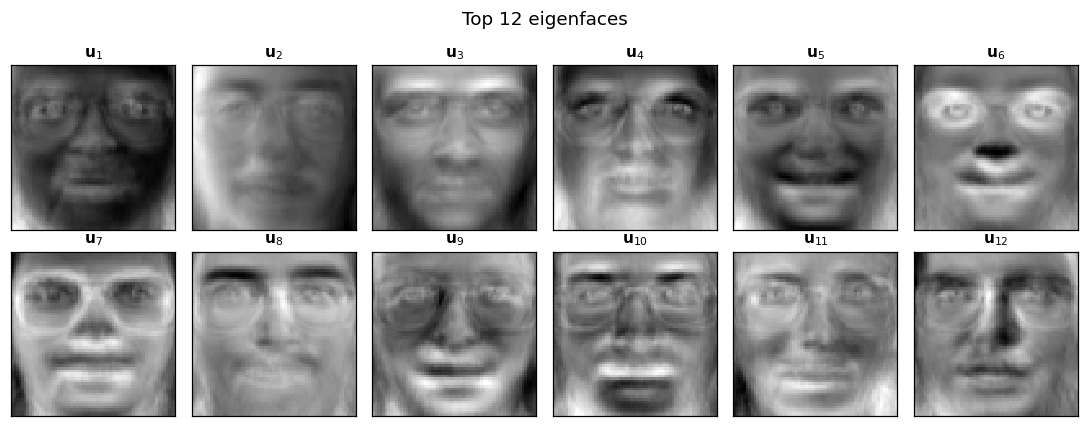

In [11]:
n_show = 12
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(U[:, i].reshape(H, W))
    ax.set_title(fr"$\mathbf{{u}}_{{{i+1}}}$", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Top 12 eigenfaces"); plt.tight_layout(); plt.show()

### Eigenvalue spectrum and choosing $M'$

The paper notes that $M' < M$ eigenfaces suffice for recognition because we don't need accurate reconstruction — only enough resolution in face space to separate identities. Sirovich & Kirby (1987) found ~40 eigenfaces gave 2% RMS reconstruction error on 115 faces; Turk & Pentland used $M' = 7$ on 16 training images.

We plot the eigenvalue spectrum and the cumulative explained variance to inform the choice of $M'$.

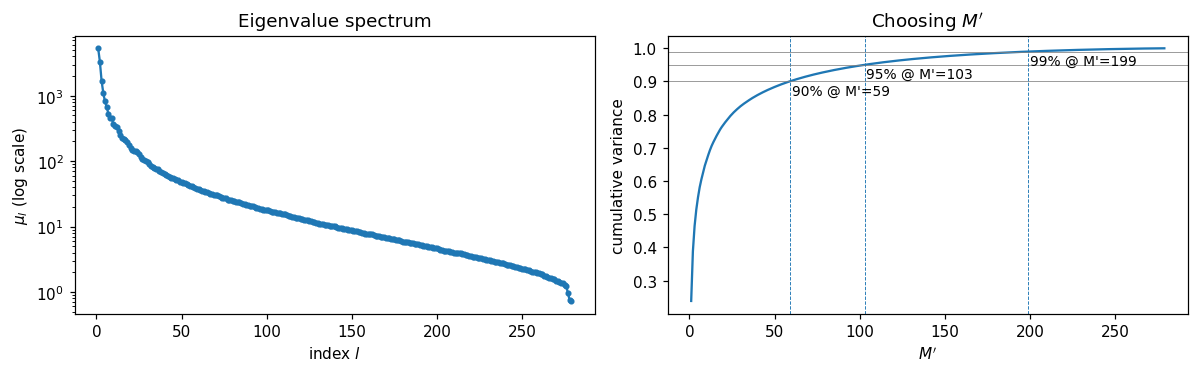

In [12]:
explained = mu / mu.sum()
cum = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].semilogy(np.arange(1, len(mu)+1), mu, ".-")
axes[0].set_xlabel(r"index $l$"); axes[0].set_ylabel(r"$\mu_l$ (log scale)")
axes[0].set_title("Eigenvalue spectrum")

axes[1].plot(np.arange(1, len(cum)+1), cum)
for thr in (0.90, 0.95, 0.99):
    k = np.searchsorted(cum, thr) + 1
    axes[1].axhline(thr, color="gray", lw=0.5)
    axes[1].axvline(k, ls="--", lw=0.6)
    axes[1].text(k+1, thr-0.04, f"{int(thr*100)}% @ M'={k}", fontsize=9)
axes[1].set_xlabel(r"$M'$"); axes[1].set_ylabel("cumulative variance")
axes[1].set_title("Choosing $M'$")
plt.tight_layout(); plt.show()

## 5. Pattern vectors $\Omega$ and class centroids $\Omega_k$

For each face image $\Gamma$, projection into face space (eq. 7) gives
$$\omega_k = \mathbf{u}_k^\top (\Gamma - \Psi), \quad k = 1, \ldots, M',$$
and stacking these into $\Omega = [\omega_1, \ldots, \omega_{M'}]^\top$.

In matrix form for the whole training set: $\Omega_{\text{train}} = U^\top (X_{\text{train}} - \Psi)^\top$.

The class centroid for subject $k$ is the average of $\Omega$ over that subject's training images (paper, step 4 of the recognition procedure):
$$\Omega_k = \frac{1}{n_k}\sum_{i \in \text{class } k}\Omega_i.$$

In [14]:
def project(X, U_k, Psi):
    """Project a batch of images (rows) onto the first U_k.shape[1] eigenfaces."""
    return (X - Psi) @ U_k                 # (n_imgs, M')

def class_centroids(Omega, y):
    classes = np.unique(y)
    return classes, np.stack([Omega[y == c].mean(axis=0) for c in classes])

# Use a chosen M' (we'll later sweep this)
Mp = 40
U_k = U[:, :Mp]

Omega_train = project(X_train, U_k, Psi)             # (M, M')
classes, Omega_centroids = class_centroids(Omega_train, y_train)
print(f"Omega_train: {Omega_train.shape},  centroids: {Omega_centroids.shape}")

Omega_train: (280, 40),  centroids: (40, 40)


## 6. Recognition: distance to class + distance to face space

For an input image $\Gamma$:

- Compute $\Omega = U^\top (\Gamma - \Psi)$.
- **In-class distance** to each known class (eq. 8): $\varepsilon_k^2 = \lVert \Omega - \Omega_k \rVert^2$.
- **Face-space distance** (eq. 9): $\varepsilon^2 = \lVert \Phi - \Phi_f \rVert^2$, where $\Phi_f = \sum_l \omega_l \mathbf{u}_l = U \Omega$ is the projection back into pixel space.

The paper's four-way decision rule (with thresholds $\theta_\varepsilon$ for class distance and $\theta_\xi$ for face-space distance) — page 76:

| | $\varepsilon_k < \theta_\varepsilon$ | $\varepsilon_k \geq \theta_\varepsilon$ |
|---|---|---|
| **$\varepsilon < \theta_\xi$** | recognized as class $k$ | unknown face |
| **$\varepsilon \geq \theta_\xi$** | (unlikely; treat as not-a-face) | not a face |

In [15]:
def classify(X, U_k, Psi, Omega_centroids, classes,
             theta_class=np.inf, theta_face=np.inf):
    """
    Returns
    -------
    pred  : (n,) predicted class id, or -1 for 'unknown', or -2 for 'not a face'
    eps_k : (n,) min in-class distance
    eps   : (n,) face-space distance
    """
    Phi  = X - Psi                              # (n, N^2)
    Om   = Phi @ U_k                            # (n, M')
    # face-space distance: ||Phi||^2 - ||Om||^2  (since cols of U_k are orthonormal)
    eps  = np.sqrt(np.maximum(
        np.einsum("ij,ij->i", Phi, Phi) - np.einsum("ij,ij->i", Om, Om),
        0.0))
    # in-class distance
    diff = Om[:, None, :] - Omega_centroids[None, :, :]
    d    = np.linalg.norm(diff, axis=2)         # (n, K)
    eps_k = d.min(axis=1)
    nearest = classes[d.argmin(axis=1)]

    pred = nearest.copy()
    pred[(eps  >= theta_face)]  = -2            # not a face
    pred[(eps  <  theta_face) & (eps_k >= theta_class)] = -1  # unknown
    return pred, eps_k, eps

pred, eps_k, eps = classify(X_test, U_k, Psi, Omega_centroids, classes)
acc = (pred == y_test).mean()
print(f"M' = {Mp}: accuracy on held-out test set = {acc:.3f} "
      f"({(pred == y_test).sum()}/{len(y_test)})")

M' = 40: accuracy on held-out test set = 0.850 (102/120)


### Accuracy as a function of $M'$

Because the projection is the same operation regardless of how many eigenfaces we keep, we can sweep $M'$ cheaply by reusing $U$.

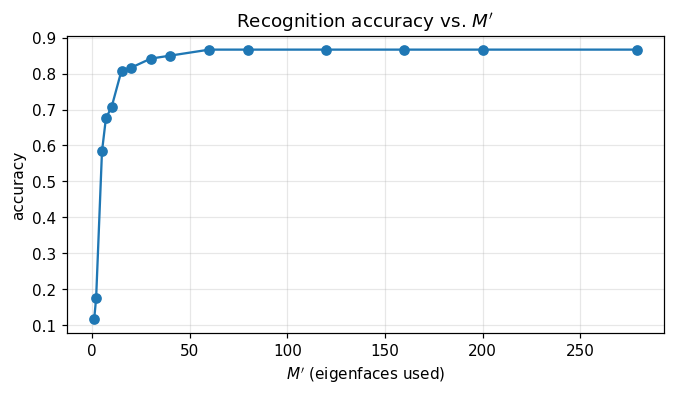

  M' =    1:  acc = 0.117
  M' =    2:  acc = 0.175
  M' =    5:  acc = 0.583
  M' =    7:  acc = 0.675
  M' =   10:  acc = 0.708
  M' =   15:  acc = 0.808
  M' =   20:  acc = 0.817
  M' =   30:  acc = 0.842
  M' =   40:  acc = 0.850
  M' =   60:  acc = 0.867
  M' =   80:  acc = 0.867
  M' =  120:  acc = 0.867
  M' =  160:  acc = 0.867
  M' =  200:  acc = 0.867
  M' =  279:  acc = 0.867


In [16]:
Mps = [1, 2, 5, 7, 10, 15, 20, 30, 40, 60, 80, 120, 160, 200, U.shape[1]]
accs = []
for k in Mps:
    Uk = U[:, :k]
    Om_tr = project(X_train, Uk, Psi)
    cls, cent = class_centroids(Om_tr, y_train)
    pr, _, _ = classify(X_test, Uk, Psi, cent, cls)
    accs.append((k, (pr == y_test).mean()))

ks = [a[0] for a in accs]; vs = [a[1] for a in accs]
plt.figure(figsize=(7, 3.5))
plt.plot(ks, vs, "o-")
plt.xlabel(r"$M'$ (eigenfaces used)"); plt.ylabel("accuracy")
plt.title(r"Recognition accuracy vs. $M'$")
plt.grid(alpha=0.3); plt.show()
for k, v in accs:
    print(f"  M' = {k:>4}:  acc = {v:.3f}")

## 7. Threshold $\theta_\varepsilon$ sweep — accuracy vs. unknown-rate tradeoff

The paper (page 81) reports varying $\theta_\varepsilon$: low values reject more inputs as "unknown" but cut errors; high values accept more but with more misclassifications. We reproduce that tradeoff curve here.

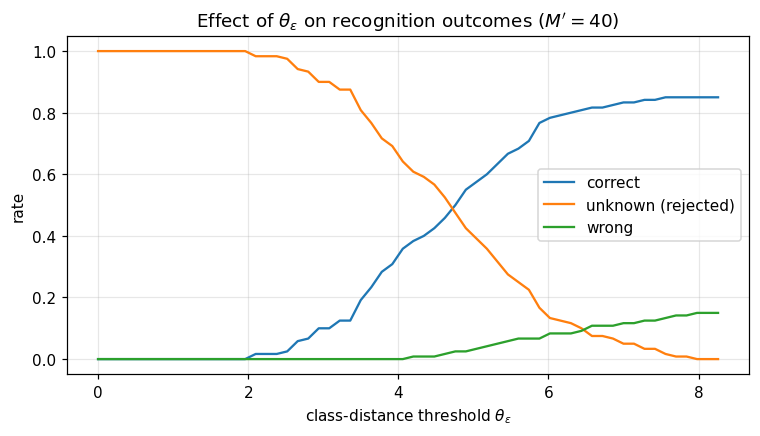

In [17]:
Uk = U[:, :40]
Om_tr = project(X_train, Uk, Psi)
cls, cent = class_centroids(Om_tr, y_train)

# Range of class-distance thresholds.
# We pick the range based on the in-class distances we actually observe.
_, eps_k_test, _ = classify(X_test, Uk, Psi, cent, cls)
thetas = np.linspace(0, eps_k_test.max() * 1.05, 60)

correct = []; unknown = []; wrong = []
for th in thetas:
    pr, _, _ = classify(X_test, Uk, Psi, cent, cls,
                        theta_class=th, theta_face=np.inf)
    is_unknown = pr == -1
    is_correct = (pr == y_test) & ~is_unknown
    is_wrong   = (pr != y_test) & ~is_unknown
    n = len(y_test)
    correct.append(is_correct.sum() / n)
    unknown.append(is_unknown.sum() / n)
    wrong.append(is_wrong.sum() / n)

plt.figure(figsize=(8, 4))
plt.plot(thetas, correct, label="correct")
plt.plot(thetas, unknown, label="unknown (rejected)")
plt.plot(thetas, wrong,   label="wrong")
plt.xlabel(r"class-distance threshold $\theta_\varepsilon$")
plt.ylabel("rate"); plt.legend(); plt.grid(alpha=0.3)
plt.title(r"Effect of $\theta_\varepsilon$ on recognition outcomes ($M' = 40$)")
plt.show()

## 8. Reconstruction demo (paper's Figure 3)

Project a held-out face into face space, then reconstruct it as $\Psi + U_{M'} \Omega$. We expect the reconstruction to look face-like even with a small $M'$, with sharper detail as $M'$ grows.

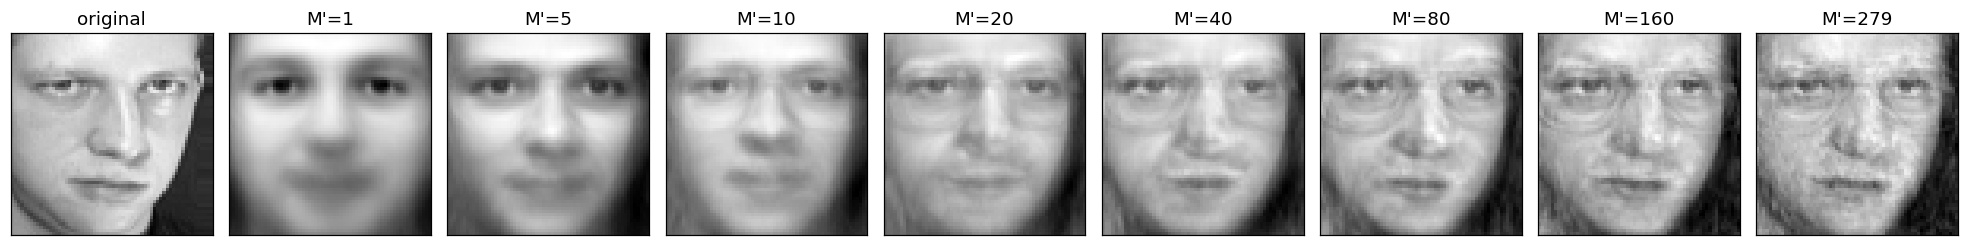

In [18]:
gamma = X_test[0]                          # (N^2,)
phi   = gamma - Psi
Mp_grid = [1, 5, 10, 20, 40, 80, 160, U.shape[1]]

fig, axes = plt.subplots(1, len(Mp_grid) + 1, figsize=(2 * (len(Mp_grid)+1), 2.5))
axes[0].imshow(gamma.reshape(H, W)); axes[0].set_title("original")
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, k in zip(axes[1:], Mp_grid):
    om = U[:, :k].T @ phi
    rec = Psi + U[:, :k] @ om
    ax.imshow(rec.reshape(H, W))
    ax.set_title(f"M'={k}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 9. "Faceness" — face-space distance for face vs. non-face inputs (paper's Figure 4)

The paper shows that a face image projects close to face space, but a flower (or any non-face) projects far from it. We illustrate the same effect by feeding three inputs:

1. A real face from the **training** set (should give the smallest $\varepsilon$).
2. A real face from the **test** set (small $\varepsilon$, slightly larger).
3. **Random noise** (large $\varepsilon$).

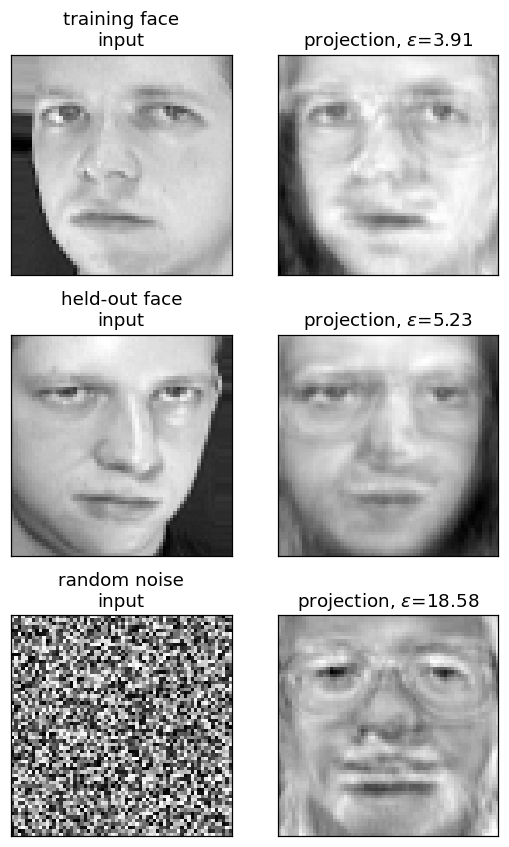

In [19]:
def project_and_distance(gamma, Uk, Psi):
    phi = gamma - Psi
    om  = Uk.T @ phi
    phi_f = Uk @ om
    eps = np.linalg.norm(phi - phi_f)
    return phi_f + Psi, eps

Uk = U[:, :40]

inputs = [
    ("training face",  X_train[0]),
    ("held-out face",  X_test[0]),
    ("random noise",   np.random.default_rng(1).random(N2)),
]

fig, axes = plt.subplots(len(inputs), 2, figsize=(5, 2.6 * len(inputs)))
for row, (label, g) in enumerate(inputs):
    rec, eps = project_and_distance(g, Uk, Psi)
    axes[row, 0].imshow(g.reshape(H, W));   axes[row, 0].set_title(f"{label}\ninput")
    axes[row, 1].imshow(rec.reshape(H, W)); axes[row, 1].set_title(rf"projection, $\varepsilon$={eps:.2f}")
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 10. Wrap-up

Reproduced from Turk & Pentland (1991):

- The mean face $\Psi$ and eigenfaces $\mathbf{u}_l$ via the $M \times M$ trick (eqs. 4–6) — verified mathematically equivalent to direct eigendecomposition of $C$, but tractable.
- Pattern-vector projection $\Omega = U^\top (\Gamma - \Psi)$ (eq. 7).
- Two-distance recognition: $\varepsilon_k$ for identity (eq. 8), $\varepsilon$ for "is this a face at all" (eq. 9).
- Threshold sweep showing the accuracy / unknown-rate / error-rate tradeoff (paper's Figure 9 / page 81 discussion).
- Reconstruction quality vs. $M'$ (Figure 3) and faceness on non-face inputs (Figure 4).

**Limitations the paper itself flags** (section *Other Issues*): this approach assumes upright, centered, scale-aligned faces. Performance "drops dramatically with size change" (page 81). A multi-scale extension (multi-scale eigenfaces, or rescaling input to match training) is needed for real-world use, plus a separate orientation estimate. None of those are implemented here — this notebook is faithful to the 1991 core algorithm.